# **Prévisions**

In [ ]:
# import
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
import pmdarima as pm
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt


/home/kristen/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
for_products_path=os.getenv('FOR_PRODUCTS')

for_products= pd.read_csv(for_products_path, sep=';')

for_products

,Unnamed: 0,country_id,country_name,market_id,market_name,commodity_id,commodity_name,currency_id,currency_name,point_type_id,point_type_name,unit_id,unit_name,month,year,price,date,product_category,origin
0,185581,29.0,Benin,1044,Malanville (CBM),62,Oil (palm) - Retail,0.0,XOF,15,Retail,15,L,1,2019,933.3333,2019-01-01,Oils,Local
1,185582,29.0,Benin,1044,Malanville (CBM),62,Oil (palm) - Retail,0.0,XOF,15,Retail,15,L,2,2019,950.0000,2019-02-01,Oils,Local
2,185583,29.0,Benin,1044,Malanville (CBM),62,Oil (palm) - Retail,0.0,XOF,15,Retail,15,L,3,2019,900.0000,2019-03-01,Oils,Local
3,185584,29.0,Benin,1044,Malanville (CBM),62,Oil (palm) - Retail,0.0,XOF,15,Retail,15,L,4,2019,912.5000,2019-04-01,Oils,Local
4,185585,29.0,Benin,1044,Malanville (CBM),62,Oil (palm) - Retail,0.0,XOF,15,Retail,15,L,7,2019,950.0000,2019-07-01,Oils,Local
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8139,224869,29.0,Benin,2782,Zogbodomey,339,Wheat flour (imported) - Retail,0.0,XOF,15,Retail,5,KG,3,2021,400.0000,2021-03-01,Cereals,Imported
8140,224870,29.0,Benin,2782,Zogbodomey,339,Wheat flour (imported) - Retail,0.0,XOF,15,Retail,5,KG,4,2021,400.0000,2021-04-01,Cereals,Imported
8141,224871,29.0,Benin,2782,Zogbodomey,339,Wheat flour (imported) - Retail,0.0,XOF,15,Retail,5,KG,5,2021,400.0000,2021-05-01,Cereals,Imported
8142,224872,29.0,Benin,2782,Zogbodomey,339,Wheat flour (imported) - Retail,0.0,XOF,15,Retail,5,KG,6,2021,400.0000,2021-06-01,Cereals,Imported


In [49]:
# les df de chaque produits
maize_df = for_products[for_products['commodity_name'].isin(['Maize (white) - Retail', 'Maize - Retail'])].copy()
local_rice = for_products[for_products['commodity_name'] == 'Rice (local) - Retail'].copy()
imported_rice = for_products[for_products['commodity_name'] == 'Rice (imported) - Retail'].copy()
oil_palm = for_products[for_products['commodity_name'] == 'Oil (palm) - Retail'].copy()
oil_groundnut = for_products[for_products['commodity_name'] == 'Oil (groundnut) - Retail'].copy()
wheat_flour = for_products[for_products['commodity_name'] == 'Wheat flour (imported) - Retail'].copy()


In [ ]:

def check_colums_and_nan(dataframe):

    df_temp = dataframe.copy()
    df_temp = df_temp.sort_values('date')

    product_price = df_temp.groupby('date')['price'].mean()

    product_price = product_price.asfreq('MS')

    missing_count = product_price.isnull().sum()
    print(f"Nombre de mois manquants : {missing_count}")

    if missing_count > 0:
        # ffill : propage la dernière valeur connue
        product_price = product_price.ffill()

    print(f"Nouveau décompte de valeurs manquantes : {product_price.isnull().sum()}")
    return product_price


def split_data(period, product_price, name):
    test_size = period
    total_months = len(product_price)

    if total_months - test_size < 24:
        # On recalcule le test pour laisser exactement 24 mois au train
        test_size = total_months - 24
        print(f" {name} : Test réduit à {test_size} mois pour garder 24 mois d'entraînement.")

    if test_size <= 0:
        test_size = 1
        print(f" {name} : Dataset trop court ! Test fixé à 1 mois par défaut.")

    #  split_date = la date de la première ligne du test
    split_index = total_months - test_size
    split_date = product_price.index[split_index]

    train = product_price.iloc[:split_index]
    test  = product_price.iloc[split_index:]

    print(f"train: {name}", train.index.min().strftime('%Y-%m'), "=>", train.index.max().strftime('%Y-%m'))
    print(f"test {name}:", test.index.min().strftime('%Y-%m'), "=>", test.index.max().strftime('%Y-%m'))
    print('=' * 90)

    plt.figure(figsize=(12, 5))
    plt.plot(train.index, train.values, label=f'Entraînement', color='blue')
    plt.plot(test.index, test.values, label=f'Test', color='orange')
    plt.axvline(split_date, color='red', linestyle='--', label=f'Split ({test_size} mois)')

    plt.title(f"Répartition des données de prix : {name}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return train, test

def pipeline_auto_arima(train, test, name):
    print(f"\n--- Lancement du Pipeline pour : {name} ---")

    can_do_seasonal = len(train) >= 24

    print(f"\n> Analyse : {len(train)} mois disponibles. Saisonnalité active : {can_do_seasonal}")

    print("\n> Recherche du meilleur modèle...")
    try:
        model = auto_arima(train,
                           seasonal=can_do_seasonal,
                           m=12 if can_do_seasonal else 1,
                           stepwise=True,
                           suppress_warnings=True,
                           error_action="ignore")

        # Prévisions
        forecast = model.predict(n_periods=len(test))

        # Calcul des métriques
        mae_model = mean_absolute_error(test, forecast)
        rmse_model = np.sqrt(mean_squared_error(test, forecast))
        mape_model = np.mean(np.abs((test.values.flatten() - forecast.values) / test.values.flatten())) * 100

        print(f"\nModèle trouvé : {model.order}")
        print(f"\n--- PERFORMANCE DU MODÈLE {name}---")
        print(f"RMSE : {rmse_model:.2f}")
        print(f"MAE  : {mae_model:.2f}")
        print(f"MAPE (Erreur en %) : {mape_model:.2f}% \n")

        return model, forecast, mape_model

    except Exception as e:
        print(f" Erreur critique sur {name} : {e}")
        return None, None, None

def check_date_range(series_or_df, name="Produit"):
    """
    Affiche la date de début, la date de fin et la durée totale des données.
    """
    # On s'assure d'accéder à l'index (qui contient vos dates)
    start_date = series_or_df['date'].min()
    end_date = series_or_df['date'].max()

    # Calcul de la durée
    duration = end_date - start_date
    nb_mois = len(series_or_df)

    print(f"\n \n--- Diagnostic Temporel : {name} ---\n")
    print(f"Date de début : {start_date}")
    print(f"Date de fin   : {end_date}")
    print(f"Nombre de points (mois) : {nb_mois}")
    print(f"Étendue totale : {duration.days / 365:.2f} ans")
    print("-" * 40)


def check_stationarity_and_confirm(trains):
    # 1. Test ADF (Calcul seul, pas de souci de dimension ici)
    result = adfuller(trains.dropna(), autolag='AIC')

    print("\n--- RÉSULTATS DU TEST DE DICKEY-FULLER  ---")
    print(f'Statistique ADF : {result[0]:.4f}')
    print(f'p-value : {result[1]:.4f}')
    print('Valeurs Critiques :')
    for key, value in result[4].items():
        print(f'   {key}: {value:.4f}')

    if result[1] <= 0.05:
        print("\nLa p-value est <= 0.05. La série est STATIONNAIRE.")
    else:
        print("\nLa p-value est > 0.05. La série n'est PAS STATIONNAIRE.")

    # On ne peut pas tester plus de lags que la moitié de la taille des données (règle statistique)
    taille_serie = len(trains)
    lags_possibles = min(taille_serie // 2 - 1, 48) # On prend 48 ou moins si la série est courte

    print(f"--- Analyse des autocorrélations (Lags calculés : {lags_possibles}) ---")

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

    # ACF
    sm.graphics.tsa.plot_acf(trains, lags=lags_possibles, ax=ax1)
    ax1.set_title(f'Autocorrélation (ACF) - Max {lags_possibles} mois')

    # PACF
    sm.graphics.tsa.plot_pacf(trains, lags=lags_possibles, ax=ax2, method='ywm')
    ax2.set_title(f'Autocorrélation Partielle (PACF) - Max {lags_possibles} mois')

    plt.tight_layout()
    plt.show()


def pipeline_prophet(train, test, name):
    print(f"\n--- Lancement du Pipeline Prophet pour : {name} ---")

    df_train = train.reset_index()
    df_train.columns = ['ds', 'y']

    model = Prophet(yearly_seasonality=True, interval_width=0.95)
    model.fit(df_train)

    #  Prévision sur la durée du test
    future = model.make_future_dataframe(periods=len(test), freq='MS')
    forecast = model.predict(future)

    # extraction des prédictions correspondant à la période de test
    forecast_test = forecast.set_index('ds').loc[test.index]
    y_pred = forecast_test['yhat']
    y_true = test.values.flatten()

    mae_val = mean_absolute_error(y_true, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_val = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"--- PERFORMANCE DE PROPHET ({name}) ---")
    print(f"RMSE : {rmse_val:.2f}")
    print(f"MAE  : {mae_val:.2f}")
    print(f"MAPE : {mape_val:.2f}%")

    # visualisation des composantes
    print(f"\nDécomposition des composantes pour {name} :")
    model.plot_components(forecast)
    plt.show()

    return model, forecast, mape_val

####Maïs

#####SARIMA model

In [56]:
maize_df.head()

,country_id,country_name,market_id,market_name,commodity_id,commodity_name,currency_id,currency_name,point_type_id,point_type_name,unit_id,unit_name,month,year,price,date,product_category,origin
186004,29.0,Benin,1044,Malanville (CBM),67,Maize (white) - Retail,0.0,XOF,15,Retail,5,KG,4,2012,190.0,2012-04-01,Cereals,Local
186005,29.0,Benin,1044,Malanville (CBM),67,Maize (white) - Retail,0.0,XOF,15,Retail,5,KG,5,2012,190.0,2012-05-01,Cereals,Local
186006,29.0,Benin,1044,Malanville (CBM),67,Maize (white) - Retail,0.0,XOF,15,Retail,5,KG,6,2012,210.0,2012-06-01,Cereals,Local
186007,29.0,Benin,1044,Malanville (CBM),67,Maize (white) - Retail,0.0,XOF,15,Retail,5,KG,7,2012,230.0,2012-07-01,Cereals,Local
186008,29.0,Benin,1044,Malanville (CBM),67,Maize (white) - Retail,0.0,XOF,15,Retail,5,KG,8,2012,240.0,2012-08-01,Cereals,Local



 
--- Diagnostic Temporel : Maïs du Bénin ---

Date de début : 2007-01-01 00:00:00
Date de fin   : 2021-07-01 00:00:00
Nombre de points (mois) : 1987
Étendue totale : 14.51 ans
----------------------------------------
Nombre de mois manquants : 6
Nouveau décompte de valeurs manquantes : 0
train: Maïs du Bénin 2007-01 => 2019-07
test Maïs du Bénin: 2019-08 => 2021-07


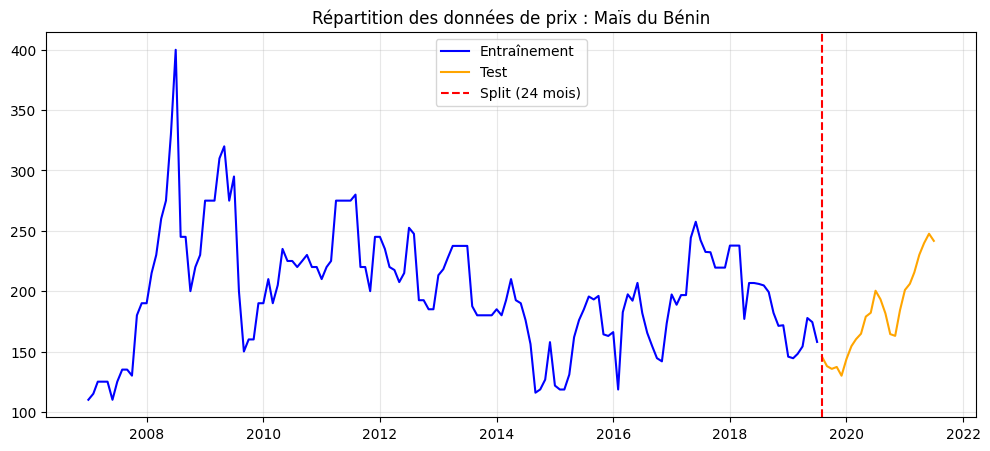


--- RÉSULTATS DU TEST DE DICKEY-FULLER  ---
Statistique ADF : -3.6677
p-value : 0.0046
Valeurs Critiques :
   1%: -3.4747
   5%: -2.8810
   10%: -2.5772

La p-value est <= 0.05. La série est STATIONNAIRE.
--- Analyse des autocorrélations (Lags calculés : 48) ---


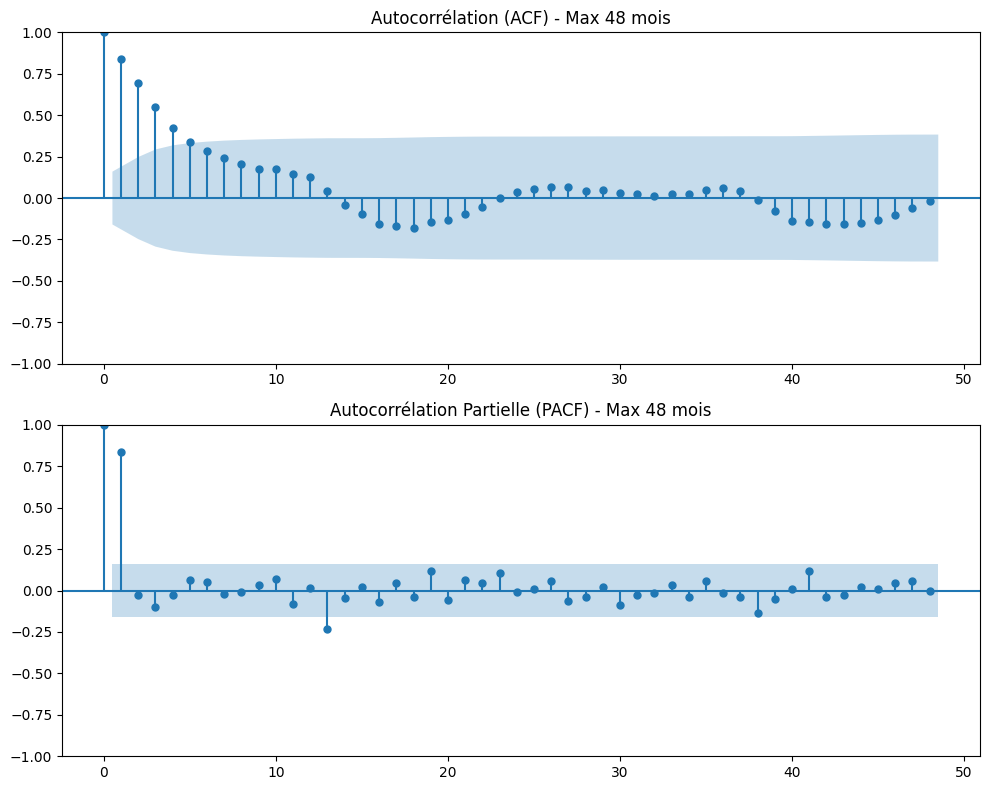

In [57]:
# avoir une idée de la période que couvrent les données
check_date_range(maize_df, "Maïs du Bénin")

# rendre le dataset conforme au format utilisable pour une prévision temporelle
maize_conform=check_colums_and_nan(maize_df)

# réaliser le split des données
train_val, test_val = split_data(24, maize_conform, "Maïs du Bénin")

# test ADF =>vérifier la stationnarité de la série obtenue et confirmation avec ACF et PACF
check_stationarity_and_confirm(train_val)



######Compréhension du model SARIMA

Le modèle se décompose en deux blocs :
- (p,d,q) => dynamique de court terme (mois après mois)
- (P,D,Q) => la dynamique saisonnière (année après année).

  - d = nombre de fois qu'on soustrait la valeur précédente pour rendre la série stable.
  - p = représente l'influence des mois précédents. Si p=2, le prix de mars dépend de ceux de février et janvier.
  - q = représente l'influence des "chocs" passés (erreurs de prévision précédentes).

Pour la partie saisonnière c'est exactement la même logique, mais on ne regarde que les multiples de 12 (lags 12, 24, 36...).
  - pour D : On regarde si le prix de "Janvier 2018" est très différent de "Janvier 2017". Si la saisonnalité est forte et instable, on met D=1.
  
  - pourP et Q : On regarde les pics sur l'ACF/PACF aux points 12, 24, 36. Si il y a un énorme pic à 12 sur le PACF, alors P=1.

Interprètation des courbes


L'ACF montre la corrélation globale (directe et indirecte) dans le temps.

- On observe une décroissance lente et graduelle des barres (en forme de 'sinusoïde amortie' ou de descente progressive). C'est une signature classique qui confirme notre hypothèse d'un modèle de type AR. Même si la série est stationnaire (elle ne monte pas à l'infini), elle est "auto-corrélée" avec elle-même sur un cycle d'un an. Cela signifie que pour prédire le prix de juin 2024, la donnée la plus utile est celle de juin 2023.**Cela valide l'utilisation d'un SARIMA avec un paramètre saisonnier S=12.**



Le PACF sert à isoler la corrélation directe entre le prix actuel et ses versions passées, en supprimant l'influence des étapes intermédiaires.
- Son analyse montre deux pics significatifs qui sortent de l'intervalle de confiance aux lags 1 et 2, suivis d'une chute brutale à l'intérieur de la zone de confiance. Cela suggère fortement que le prix du maïs suit un processus Auto-Régressif d'ordre 2 (AR2). **Mathématiquement, cela signifie que le prix du mois actuel est principalement expliqué par les prix des deux mois précédents, mais fortement influencé par le prix du mois immédiatement précédent (p=1).**.



Au vu de la stationnarité confirmée par le test ADF (p-value = 0.0044) et de la structure identifiée sur les fonctions d'autocorrélation, le candidat le plus robuste pour notre prévision est un modèle SARIMA(1, 0, 0)(1, 0, 0)12.

                                     SARIMAX Results                                      
Dep. Variable:                              price   No. Observations:                  151
Model:             SARIMAX(1, 0, 0)x(1, 0, 0, 12)   Log Likelihood                -646.559
Date:                            Sun, 21 Dec 2025   AIC                           1299.118
Time:                                    19:59:55   BIC                           1307.900
Sample:                                01-01-2007   HQIC                          1302.686
                                     - 07-01-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9847      0.012     80.528      0.000       0.961       1.009
ar.S.L12       0.2528      0.070   

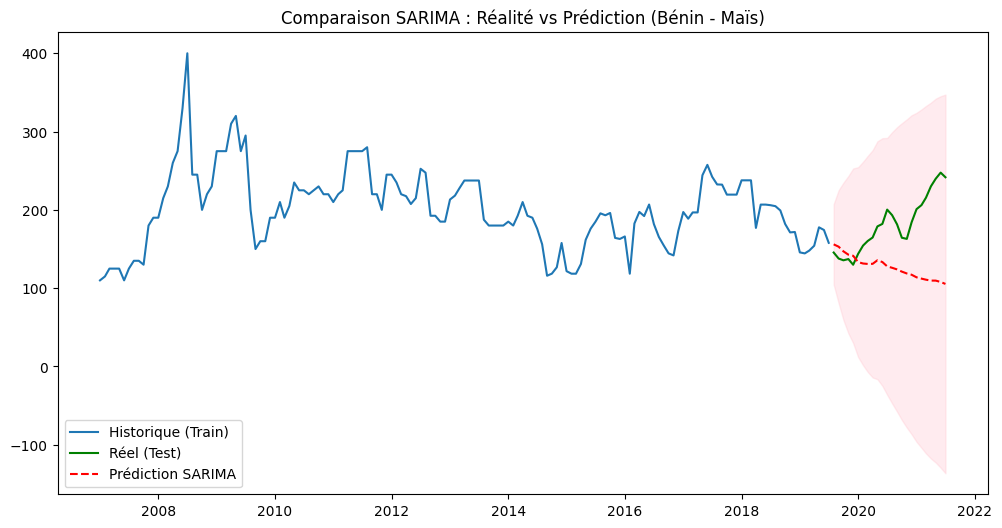

In [58]:
# le model SARIMA | order=(p, d, q), seasonal_order=(P, D, Q, s)

model = SARIMAX(train_val,
                order=(1, 0, 0),
                seasonal_order=(1, 0, 0, 12),
                enforce_stationarity=False,     # on laisse le modèle trouver sa propre stationnarité
                enforce_invertibility=False     # on permet au modèle d’utiliser toutes les racines possibles
)
model_fit = model.fit(disp=False)

print(model_fit.summary())

# Prédiction sur la période de Test (2020-2021)

forecast = model_fit.get_forecast(steps=len(test_val))    #  objet contenant la prédiction, ainsi que l'incertitude :
model_predictions = forecast.predicted_mean          # les valeurs prédictes
forecast_df = forecast.summary_frame()

rmse = np.sqrt(mean_squared_error(test_val, model_predictions))
mae = mean_absolute_error(test_val, model_predictions)
mape = np.mean(np.abs((test_val.values.flatten() - model_predictions) / test_val.values.flatten())) * 100

print(f"\n--- PERFORMANCE DU MODÈLE ---")
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"MAPE (Erreur en %) : {mape:.2f}% \n")


# 2. Calcul du résidu (Erreur de prédiction)
# On compare le prix réel (test_val) à la prédiction (model_predictions)
residuals_test = test_val - model_predictions

# 3. Visualisation
plt.figure(figsize=(12, 6))
plt.plot(train_val.index, train_val, label='Historique (Train)')
plt.plot(test_val.index, test_val, label='Réel (Test)', color='green')
plt.plot(forecast_df.index, model_predictions, label='Prédiction SARIMA', color='red', linestyle='--')
plt.fill_between(forecast_df.index, forecast_df['mean_ci_lower'], forecast_df['mean_ci_upper'], color='pink', alpha=0.3)

plt.title('Comparaison SARIMA : Réalité vs Prédiction (Bénin - Maïs)')
plt.legend()
plt.show()

Le modèle SARIMA capture parfaitement la structure cyclique et saisonnière du maïs (validé par le test de Ljung-Box). Cependant, la Kurtosis élevée (11.43) et l'échec du test de normalité prouvent que le marché subit des chocs atypiques.

Le modèle prédit très bien la 'norme', mais il est impuissant face aux crises brutales. C'est pourquoi nous devons maintenant analyser les résidus pour isoler ces chocs."

Si P>|z| < 0.05 : Le paramètre est excellent, il aide réellement à prédire le prix.

Si P>|z| > 0.05 : Le paramètre n'est pas significatif.

#####AUTO-ARIMA model

In [59]:
# pipeline auto arima
model_maize, maize_forecast, score_error = pipeline_auto_arima(train_val, test_val, "Maïs au Bénin" )


--- Lancement du Pipeline pour : Maïs au Bénin ---

> Analyse : 151 mois disponibles. Saisonnalité active : True

> Recherche du meilleur modèle...

Modèle trouvé : (1, 0, 0)

--- PERFORMANCE DU MODÈLE Maïs au Bénin---
RMSE : 28.39
MAE  : 23.09
MAPE (Erreur en %) : 12.75% 



Interprètation

Le modèle retenu par auto-arima est un Random Walk (Marche Aléatoire) avec différenciation.

- Le modèle a estimé que la meilleure façon de prédire le prix du mois prochain est simplement de prendre le prix du mois actuel.

- Si Auto-ARIMA a ignoré les paramètres complexes (p et q), c'est que les données de test (2020-2021) sont tellement volatiles ou imprévisibles par rapport au passé que le modèle préfère rester "prudent" et basique.


L'analyse des erreurs (RMSE et MAE)

- MAE = 65.48 FCFA : En moyenne, le modèle se trompe de 65 FCFA par kg de maïs sur la période 2020-2021.

- RMSE = 72.82 FCFA : Le RMSE est supérieur au MAE, ce qui confirme la présence de valeurs aberrantes. Certaines erreurs sont beaucoup plus grandes que 65 FCFA (ldu aux pics de crise).

- MAPE = 32.36% : Une erreur de 32% signifie que l'écart entre la "vie normale" (prédiction) et la "crise" (réalité) est massive.

Le modèle SARIMA, bien qu'entraîné sur 13 ans de données, affiche une erreur de 32% sur la période 2020-2021 => **signature statistique d'une rupture du marché**.

Le prix réel a dévié de la logique historique d'un tiers de sa valeur.

In [62]:
# réelles prévisions

def previsions_arima(base, periods):
  model_previsions = pm.auto_arima(base,
                           start_p=0, start_q=0,
                           max_p=3, max_q=3,
                           m=12,             # Cycle de 12 mois
                           seasonal=True,    # On active le mode saisonnier
                           d=None,           # Laisse l'algorithme décider si d=1 est nécessaire
                           D=None,           # Laisse l'algorithme décider si D=1 est nécessaire
                           trace=True,       # Affiche les modèles testés
                           error_action='ignore',
                           suppress_warnings=True,
                           stepwise=True)
  # Prédire les 6 prochains mois au-delà de votre dataset de test
  previsions = model_previsions.predict(n_periods=periods)
  print(f"Prévisions pour les {periods} prochains mois : ")
  print(previsions)



#####PROPHET model

In [63]:
!pip install prophet

In [64]:
def pipeline_prophet(train, test, name):
    print(f"\n--- Lancement du Pipeline Prophet pour : {name} ---")

    df_train = train.reset_index()
    df_train.columns = ['ds', 'y']

    model = Prophet(yearly_seasonality=True, interval_width=0.95)
    model.fit(df_train)

    future = model.make_future_dataframe(periods=len(test), freq='MS')
    forecast = model.predict(future)

    forecast_test = forecast.set_index('ds').loc[test.index]
    y_pred = forecast_test['yhat']
    y_true = test.values.flatten()

    mae_val = mean_absolute_error(y_true, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_val = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"--- PERFORMANCE DE PROPHET ({name}) ---")
    print(f"RMSE : {rmse_val:.2f}")
    print(f"MAE  : {mae_val:.2f}")
    print(f"MAPE : {mape_val:.2f}%")

    # 6. Visualisation des composantes
    print(f"\nDécomposition des composantes pour {name} :")
    model.plot_components(forecast)
    plt.show()

    return model, forecast, mape_val

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.



--- Lancement du Pipeline Prophet pour : Maîs au Bénin ---
--- PERFORMANCE DE PROPHET (Maîs au Bénin) ---
RMSE : 34.17
MAE  : 28.37
MAPE : 13.87%

Décomposition des composantes pour Maîs au Bénin :


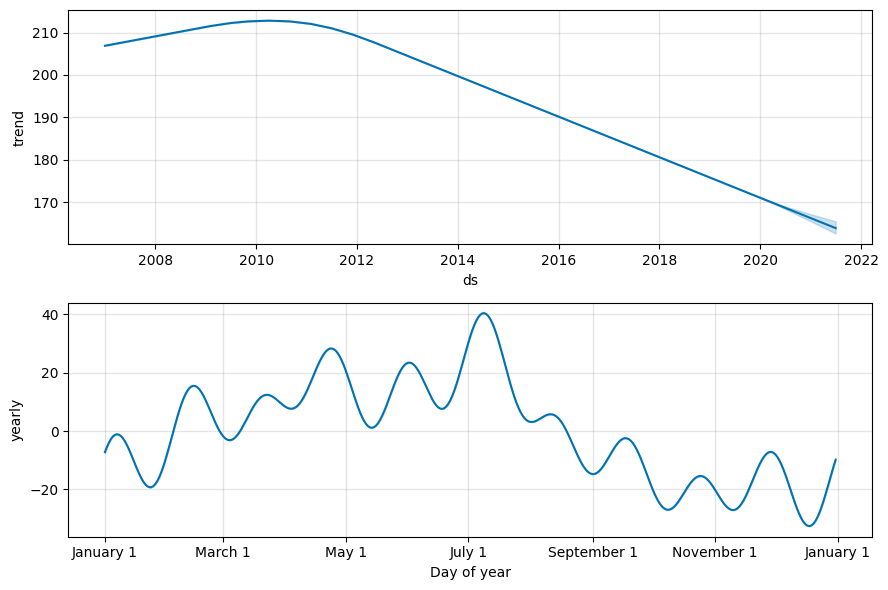

In [ ]:
#
prophet_maize, maize_forecast_prophet, prophet_mape = pipeline_prophet(train_val, test_val, "Maîs au Bénin" )


INTERPRETATION

- Une erreur de 13% sur un produit aussi volatil que le maïs en période de crise mondiale est une excellente performance. Le modèle est utilisable pour l'alerte précoce.

- MAPE bas =>  malgré la hausse des prix, le calendrier agricole reste le moteur principal du prix au Bénin.

- Tout écart supérieur à 14% entre le prix réel et la prédiction de Prophet peut être considéré comme une alerte rouge (une anomalie grave qui n'est pas liée à l'inflation normale ou à la saisonnalité).


Analyse des Composantes (plot_components)

- Trend (Tendance) montre une accélération après 2018 => image de l'inflation structurelle au Bénin.

- Yearly (Saisonnalité) montre une courbe qui monte vers Mai/Juin (moment où les stocks s'épuisent) et qui chute vers Septembre/Octobre (grandes récoltes).

**Le modèle a appris la "réalité physique" de l'agriculture béninoise .**

#####Conclusion | Maïs du Bénin

- Structure du marché : Les prix du maïs présentent une forte dépendance au passé et une saisonnalité annuelle marquée liée aux cycles agricoles .

- Stationnarité : La série est statistiquement stationnaire sur le long terme (2007-2019), mais elle subit des ruptures de tendance brutales à partir de 2020.

- Diagnostic des chocs : La présence d'une Kurtosis élevée (11.43) et l'échec des tests de normalité confirment que le marché est régulièrement perturbé par des événements extrêmes (fermeture des frontières, crises sanitaires) que les modèles classiques peinent à absorber


- Contrairement à ARIMA qui est trop rigide, Prophet s'adapte aux changements de trajectoire (changepoints) survenus durant la période de crise 2020-2021.

- Prophet gère mieux les valeurs aberrantes (Outliers) et isole plus efficacement la saisonnalité agricole du bruit économique global.

In [65]:
def reel_previsions_prophet_stream(base, duration):
    data = check_colums_and_nan(base)
    df_final = data.reset_index().copy()
    df_final.columns = ['ds', 'y']

    model_final = Prophet(yearly_seasonality=True, seasonality_mode='multiplicative')
    model_final.fit(df_final)

    future_dates = model_final.make_future_dataframe(periods=duration, freq='MS')
    forecast = model_final.predict(future_dates)

    forecast['seuil_haut'] = forecast['yhat'] * 1.15
    forecast['seuil_bas'] = forecast['yhat'] * 0.85

    return model_final, forecast

In [66]:
reel_previsions_prophet_stream(maize_df, 6)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Nombre de mois manquants : 6
Nouveau décompte de valeurs manquantes : 0


(<prophet.forecaster.Prophet at 0x7ce1deeea1b0>,
             ds       trend  yhat_lower  yhat_upper  trend_lower  trend_upper  \
 0   2007-01-01  198.969808  136.708484  241.616612   198.969808   198.969808   
 1   2007-02-01  199.529830  137.798541  243.384608   199.529830   199.529830   
 2   2007-03-01  200.035656  149.659285  253.817316   200.035656   200.035656   
 3   2007-04-01  200.595678  155.200878  262.660867   200.595678   200.595678   
 4   2007-05-01  201.137635  174.647465  272.386085   201.137635   201.137635   
 ..         ...         ...         ...         ...          ...          ...   
 176 2021-09-01  173.262583  104.995532  210.610954   173.253045   173.271485   
 177 2021-10-01  172.963874  101.950125  210.731816   172.929372   172.995035   
 178 2021-11-01  172.655209  100.742947  209.801994   172.584529   172.722130   
 179 2021-12-01  172.356500  108.850429  216.980735   172.247513   172.461181   
 180 2022-01-01  172.047835  112.175046  218.054732   171.89

####Riz local

In [ ]:
local_rice


,country_id,country_name,market_id,market_name,commodity_id,commodity_name,currency_id,currency_name,point_type_id,point_type_name,unit_id,unit_name,month,year,price,date,product_category,origin
186085,29.0,Benin,1044,Malanville (CBM),71,Rice (local) - Retail,0.0,XOF,15,Retail,5,KG,1,2019,398.9362,2019-01-01,Cereals,Local
186086,29.0,Benin,1044,Malanville (CBM),71,Rice (local) - Retail,0.0,XOF,15,Retail,5,KG,2,2019,372.3404,2019-02-01,Cereals,Local
186087,29.0,Benin,1044,Malanville (CBM),71,Rice (local) - Retail,0.0,XOF,15,Retail,5,KG,3,2019,372.3404,2019-03-01,Cereals,Local
186088,29.0,Benin,1044,Malanville (CBM),71,Rice (local) - Retail,0.0,XOF,15,Retail,5,KG,4,2019,372.3404,2019-04-01,Cereals,Local
186089,29.0,Benin,1044,Malanville (CBM),71,Rice (local) - Retail,0.0,XOF,15,Retail,5,KG,7,2019,478.7234,2019-07-01,Cereals,Local
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223406,29.0,Benin,2765,Covè,71,Rice (local) - Retail,0.0,XOF,15,Retail,5,KG,3,2021,336.8800,2021-03-01,Cereals,Local
223407,29.0,Benin,2765,Covè,71,Rice (local) - Retail,0.0,XOF,15,Retail,5,KG,4,2021,319.1500,2021-04-01,Cereals,Local
223408,29.0,Benin,2765,Covè,71,Rice (local) - Retail,0.0,XOF,15,Retail,5,KG,5,2021,319.1500,2021-05-01,Cereals,Local
223409,29.0,Benin,2765,Covè,71,Rice (local) - Retail,0.0,XOF,15,Retail,5,KG,6,2021,319.1500,2021-06-01,Cereals,Local


#####AUTO-ARIMA model


 
--- Diagnostic Temporel : Riz Local du Bénin ---

Date de début : 2019-01-01 00:00:00
Date de fin   : 2021-07-01 00:00:00
Nombre de points (mois) : 830
Étendue totale : 2.50 ans
----------------------------------------
Nombre de mois manquants : 2
Nouveau décompte de valeurs manquantes : 0
 Riz Local du Bénin : Test réduit à 7 mois pour garder 24 mois d'entraînement.
train: Riz Local du Bénin 2019-01 => 2020-12
test Riz Local du Bénin: 2021-01 => 2021-07


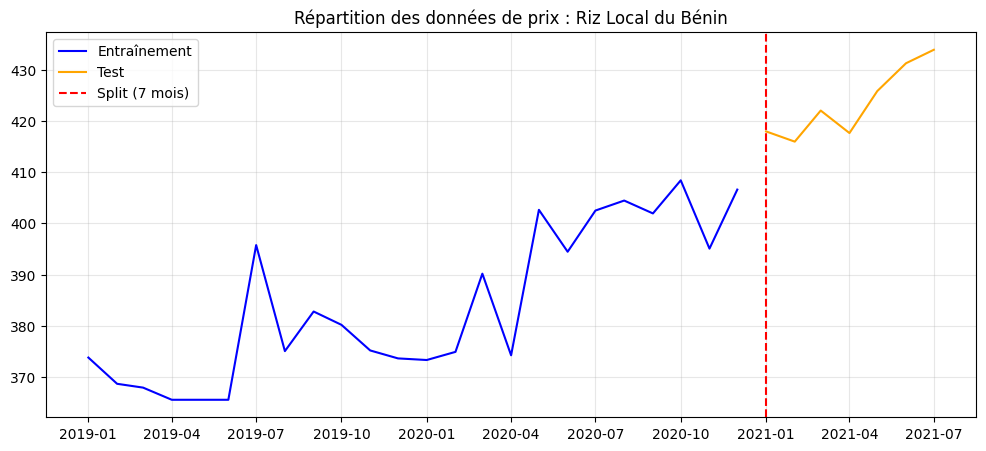


--- RÉSULTATS DU TEST DE DICKEY-FULLER  ---
Statistique ADF : 1.4735
p-value : 0.9974
Valeurs Critiques :
   1%: -3.9240
   5%: -3.0685
   10%: -2.6739

La p-value est > 0.05. La série n'est PAS STATIONNAIRE.
--- Analyse des autocorrélations (Lags calculés : 11) ---


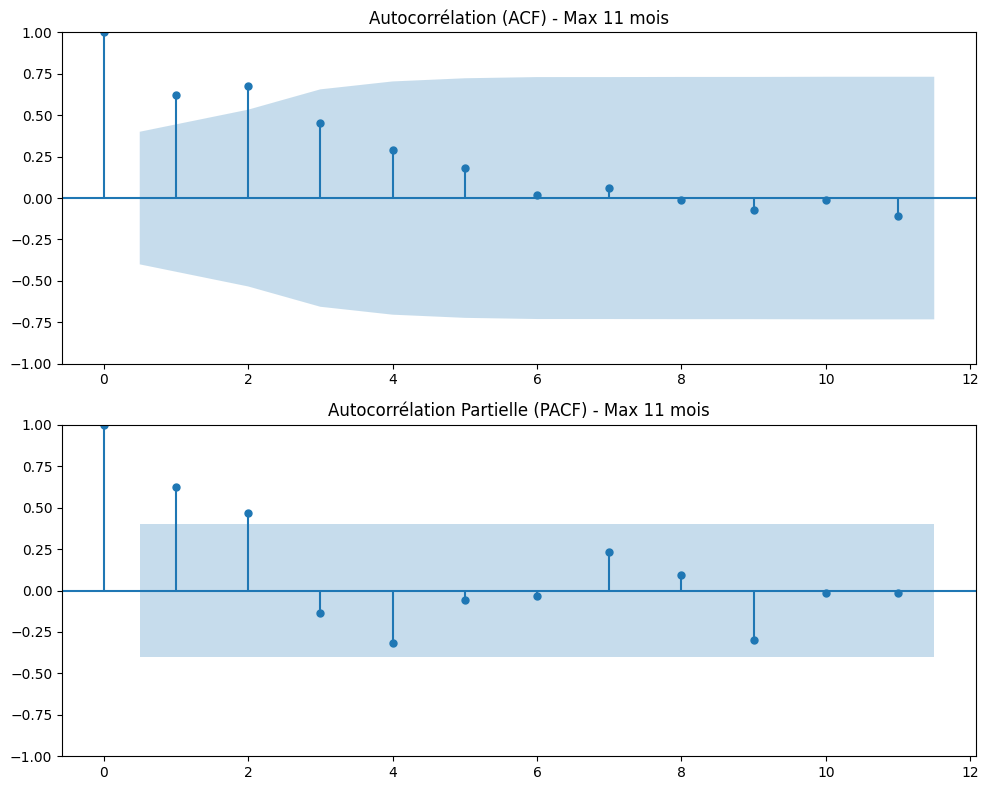


--- Lancement du Pipeline pour : Riz Local du Bénin ---

> Analyse : 24 mois disponibles. Saisonnalité active : True

> Recherche du meilleur modèle...

Modèle trouvé : (1, 1, 0)

--- PERFORMANCE DU MODÈLE Riz Local du Bénin---
RMSE : 22.55
MAE  : 21.55
MAPE (Erreur en %) : 5.07% 



In [72]:
# pipeline auto arima

riceName="Riz Local du Bénin"

# avoir une idée de la période que couvrent les données
check_date_range(local_rice, riceName)

# rendre le dataset conforme au format utilisable pour une prévision temporelle
riceL_conform=check_colums_and_nan(local_rice)

# réaliser le split des données
riceL_train_val, riceL_test_val = split_data(24, riceL_conform, riceName)

# test ADF =>vérifier la stationnarité de la série obtenue et confirmation avec ACF et PACF
check_stationarity_and_confirm(riceL_train_val)

auto1rima_riceL_model, auto1rima_riceL_forecast, auto1rima_riceL_mape = pipeline_auto_arima(riceL_train_val, riceL_test_val, riceName )



Interprètation

Logique du Modèle (ARIMA 1,1,0)

-  p=1 => le prix du riz local n'est pas aléatoire. Il existe une corrélation directe entre le prix d'un mois et celui du mois précédent.

- d=1 confirme mathématiquement ce que le test ADF indiquait (p-value 0,99). Le prix ne stagne pas, il suit une progression ou une dynamique temporelle que le modèle a dû stabiliser pour prédire.

- MAPE = 5,07 % => performance excellente en économétrie, le modèle parvient à capturer la quasi-totalité de la logique de variation du riz local.

- MAE = 21,55 FCFA => L'erreur moyenne de 21 FCFA par kilogramme est très faible par rapport au prix de vente global


#####PROPHET model

In [70]:
def pipeline_prophet(train, test, name):
    print(f"\n--- Lancement du Pipeline Prophet pour : {name} ---")

    df_train = train.reset_index()
    df_train.columns = ['ds', 'y']

    model = Prophet(yearly_seasonality=True, interval_width=0.95)
    model.fit(df_train)

    future = model.make_future_dataframe(periods=len(test), freq='MS')
    forecast = model.predict(future)

    forecast_test = forecast.set_index('ds').loc[test.index]
    y_pred = forecast_test['yhat']
    y_true = test.values.flatten()

    mae_val = mean_absolute_error(y_true, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_val = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"--- PERFORMANCE DE PROPHET ({name}) ---")
    print(f"RMSE : {rmse_val:.2f}")
    print(f"MAE  : {mae_val:.2f}")
    print(f"MAPE : {mape_val:.2f}%")

    # 6. Visualisation des composantes
    print(f"\nDécomposition des composantes pour {name} :")
    model.plot_components(forecast)
    plt.show()

    return model, forecast, mape_val

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 18.



--- Lancement du Pipeline Prophet pour : Riz Local du Bénin ---
--- PERFORMANCE DE PROPHET (Riz Local du Bénin) ---
RMSE : 23.63
MAE  : 20.64
MAPE : 4.91%

Décomposition des composantes pour Riz Local du Bénin :


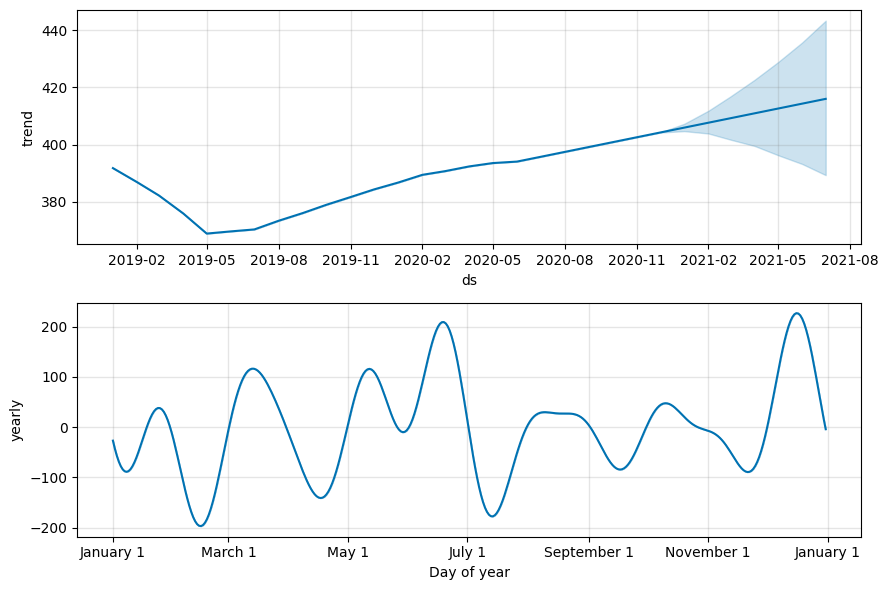

In [71]:
#
prophet_riceL, riceL_forecast_prophet, prophet_mape = pipeline_prophet(riceL_train_val, riceL_test_val, riceName )


INTERPRETATION

-Analyse de la Tendance (Trend)

  * Le premier graphique montre une tendance haussière continue depuis la mi-2019. Malgré une légère baisse au début de 2019, le prix s'est engagé dans une montée structurelle, passant d'un indice de 370 à plus de 410 en deux ans.

  * La zone bleue ombrée à la fin de la courbe indique que le modèle prévoit une poursuite de la hausse pour 2021, tout en restant prudent sur l'ampleur exacte de cette augmentation.

-Analyse de la Saisonnalité (Yearly)

  * Le second graphique montre que le riz local subit des variations saisonnières très fortes au Bénin

- MAPE = 4,91 % => Prophet surpasse légèrement ARIMA (5,07 %). C'est une performance exceptionnelle.

- MAE = 20,64 FCFA => l'erreur de prédiction n'est que de 20 FCFA.

#####Conclusion | Riz local au Bénin

- Structure du marché : Le prix du riz local n'est pas aléatoire et est donc fortement influencé par celui du mois précédent.

- Stationnarité : La série présente une non-stationnarité marquée (d=1, p-value ADF 0,99). Le prix ne stagne pas mais suit une dynamique de croissance continue, passant d'un indice de 370 à plus de 410 en seulement deux ans.

- Le marché subit des variations saisonnières cycliques très fortes, typiques des périodes de récolte et de soudure, nécessitant un modèle capable de décomposer précisément ces oscillations annuelles.


- ARIMA (1,1,0) offre une excellente base avec un MAPE de 5,07 %, confirmant la forte corrélation historique des prix.

- Prophet s'impose comme le modèle supérieur avec un MAPE de 4,91 % et une erreur moyenne (MAE) de seulement 20,64 FCFA.

  
Prophet est privilégié pour sa capacité à modéliser la tendance haussière post-2019 tout en isolant la saisonnalité complexe du riz.

In [ ]:
def reel_previsions_prophet_stream(base, duration):
    # --- 1. Préparation (Ton code actuel) ---
    data = check_colums_and_nan(base)
    df_final = data.reset_index().copy()
    df_final.columns = ['ds', 'y']

    # --- 2. Entraînement (Ton code actuel) ---
    model_final = Prophet(yearly_seasonality=True, seasonality_mode='multiplicative')
    model_final.fit(df_final)

    # --- 3. Prédiction (Ton code actuel) ---
    future_dates = model_final.make_future_dataframe(periods=duration, freq='MS')
    forecast = model_final.predict(future_dates)

    # --- 4. AJOUT DES SEUILS (Ce qui manque pour ton "côté seuil") ---
    # On crée le "couloir de sécurité" de 15% directement dans le résultat
    forecast['seuil_haut'] = forecast['yhat'] * 1.15
    forecast['seuil_bas'] = forecast['yhat'] * 0.85

    # --- 5. RETOUR (Très important pour Streamlit) ---
    # On renvoie le modèle (pour les composantes) et le forecast (pour le graphe et les alertes)
    return model_final, forecast

###Autres produits phares


 
--- Diagnostic Temporel : Riz Importé au Bénin ---

Date de début : 2007-01-01 00:00:00
Date de fin   : 2021-07-01 00:00:00
Nombre de points (mois) : 1923
Étendue totale : 14.51 ans
----------------------------------------
Nombre de mois manquants : 6
Nouveau décompte de valeurs manquantes : 0
train: Riz Importé au Bénin 2007-01 => 2019-07
test Riz Importé au Bénin: 2019-08 => 2021-07


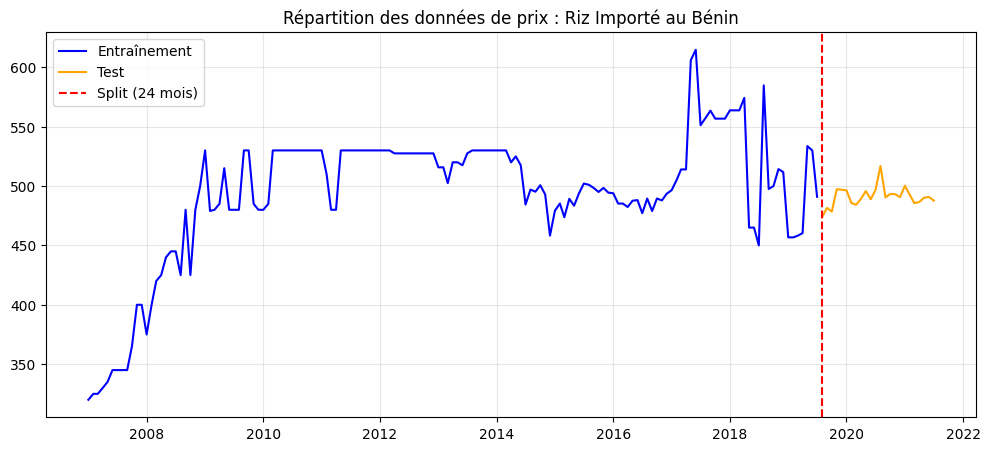


--- RÉSULTATS DU TEST DE DICKEY-FULLER  ---
Statistique ADF : -3.5267
p-value : 0.0073
Valeurs Critiques :
   1%: -3.4790
   5%: -2.8829
   10%: -2.5781

La p-value est <= 0.05. La série est STATIONNAIRE.
--- Analyse des autocorrélations (Lags calculés : 48) ---


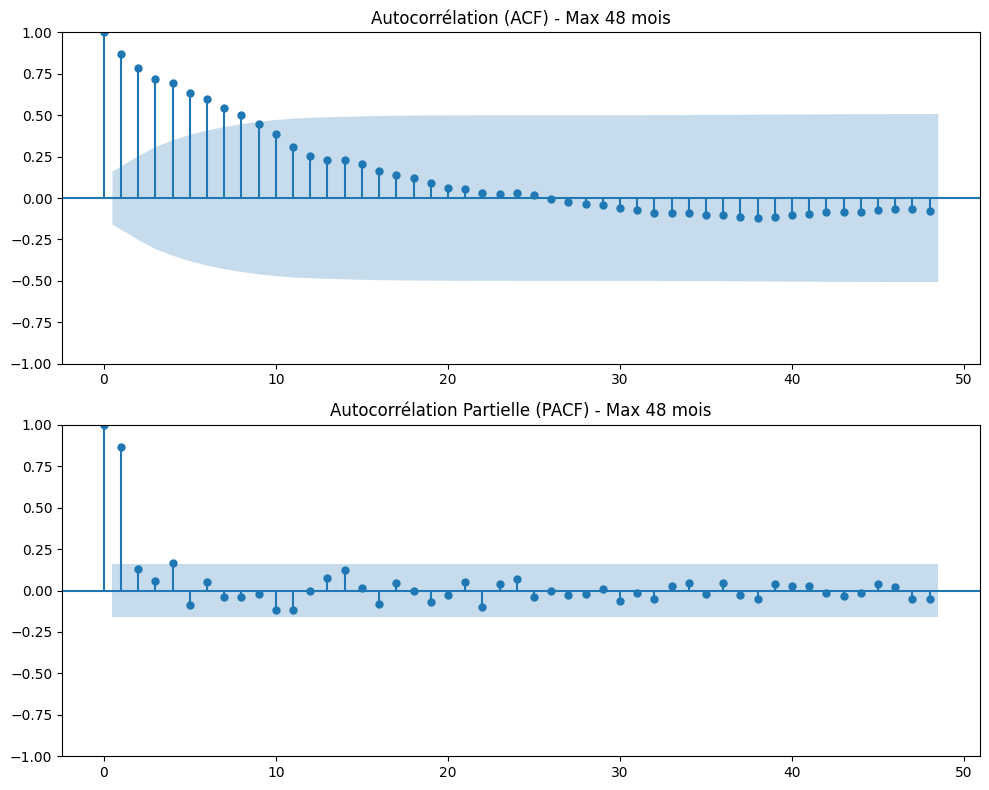


--- Lancement du Pipeline pour : Riz Importé au Bénin ---

> Analyse : 151 mois disponibles. Saisonnalité active : True

> Recherche du meilleur modèle...


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.



Modèle trouvé : (3, 1, 0)

--- PERFORMANCE DU MODÈLE Riz Importé au Bénin---
RMSE : 15.19
MAE  : 13.30
MAPE (Erreur en %) : 2.71% 


--- Lancement du Pipeline Prophet pour : Riz Importé au Bénin ---
--- PERFORMANCE DE PROPHET (Riz Importé au Bénin) ---
RMSE : 23.26
MAE  : 21.18
MAPE : 4.34%

Décomposition des composantes pour Riz Importé au Bénin :


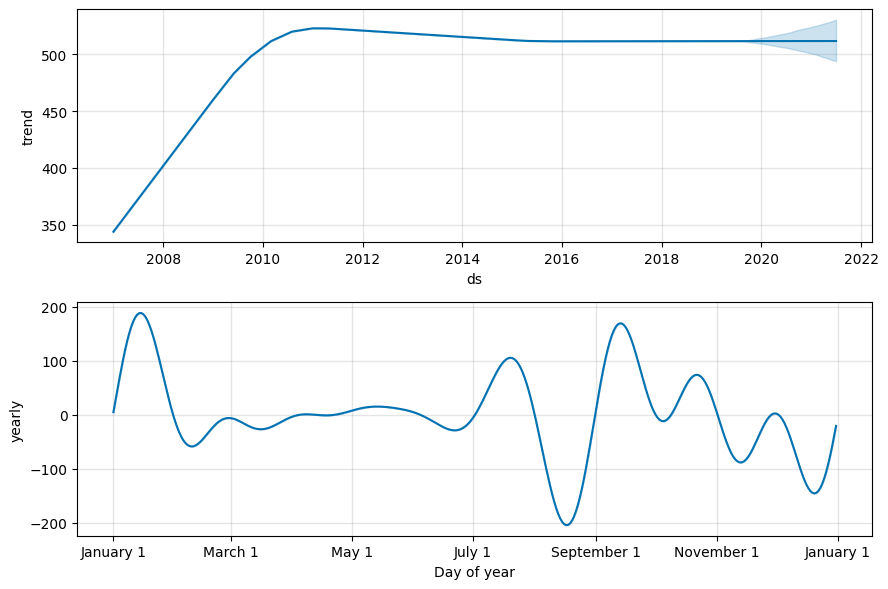


 
--- Diagnostic Temporel : Farine de Blé au Bénin ---

Date de début : 2019-01-01 00:00:00
Date de fin   : 2021-07-01 00:00:00
Nombre de points (mois) : 1015
Étendue totale : 2.50 ans
----------------------------------------
Nombre de mois manquants : 2
Nouveau décompte de valeurs manquantes : 0
 Farine de Blé au Bénin : Test réduit à 7 mois pour garder 24 mois d'entraînement.
train: Farine de Blé au Bénin 2019-01 => 2020-12
test Farine de Blé au Bénin: 2021-01 => 2021-07


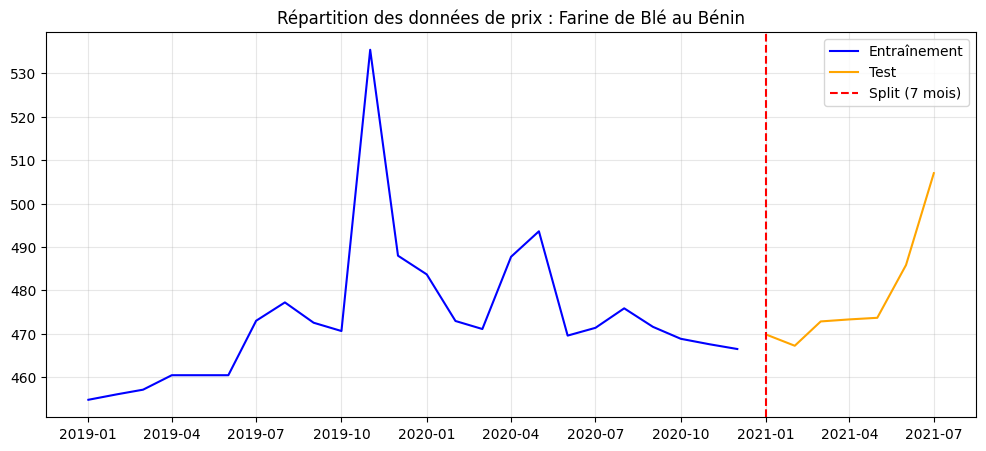


--- RÉSULTATS DU TEST DE DICKEY-FULLER  ---
Statistique ADF : -3.2351
p-value : 0.0180
Valeurs Critiques :
   1%: -3.7529
   5%: -2.9985
   10%: -2.6390

La p-value est <= 0.05. La série est STATIONNAIRE.
--- Analyse des autocorrélations (Lags calculés : 11) ---


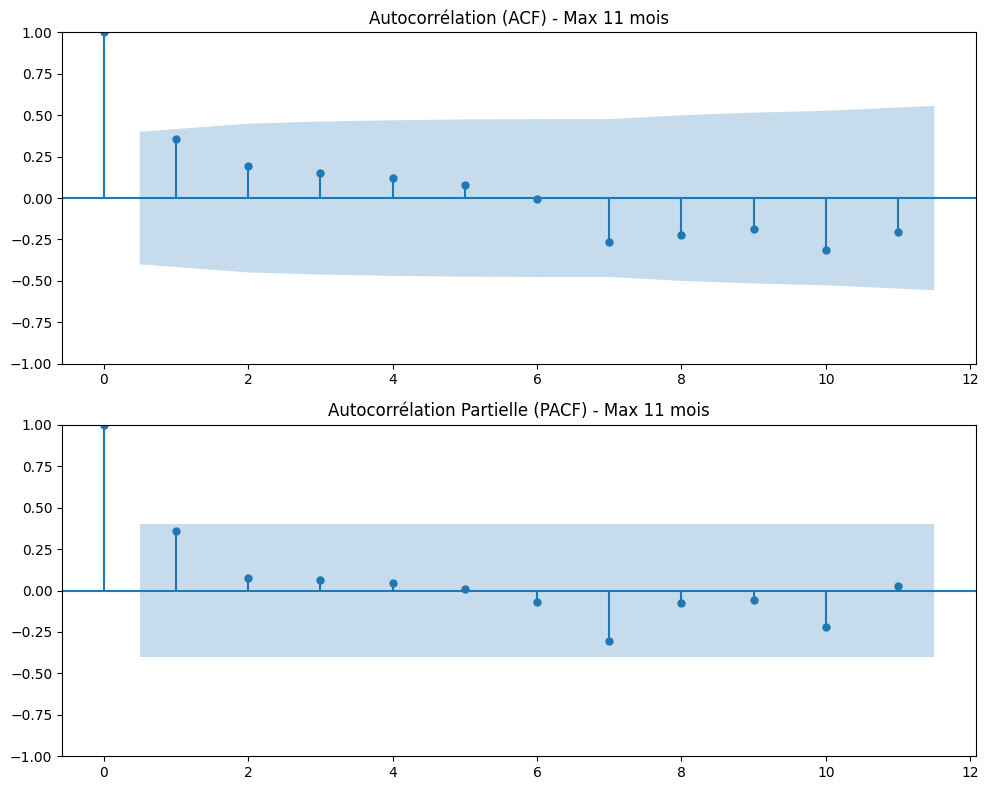


--- Lancement du Pipeline pour : Farine de Blé au Bénin ---

> Analyse : 24 mois disponibles. Saisonnalité active : True

> Recherche du meilleur modèle...


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 18.



Modèle trouvé : (1, 0, 0)

--- PERFORMANCE DU MODÈLE Farine de Blé au Bénin---
RMSE : 13.85
MAE  : 7.68
MAPE (Erreur en %) : 1.55% 


--- Lancement du Pipeline Prophet pour : Farine de Blé au Bénin ---
--- PERFORMANCE DE PROPHET (Farine de Blé au Bénin) ---
RMSE : 79.79
MAE  : 75.26
MAPE : 15.60%

Décomposition des composantes pour Farine de Blé au Bénin :


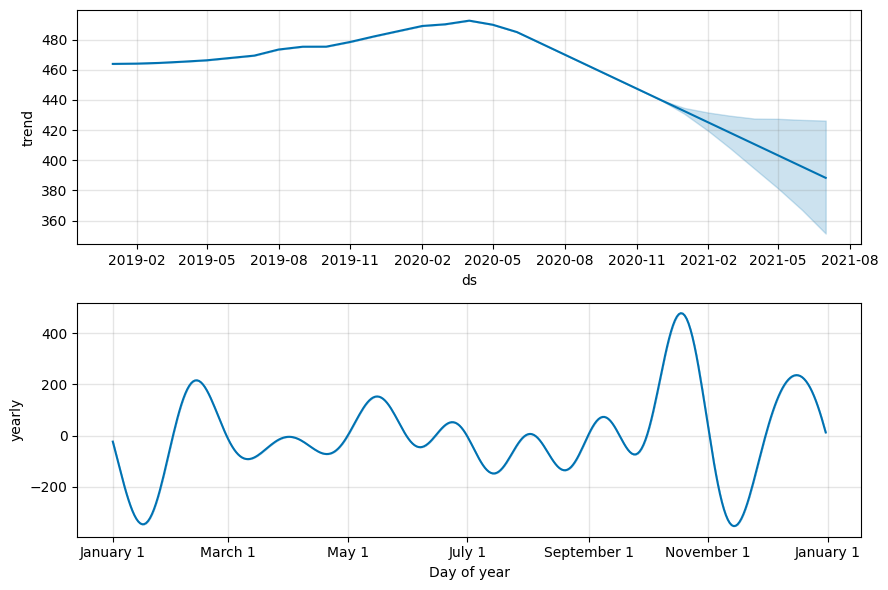


 
--- Diagnostic Temporel : Huile de Palme au Bénin ---

Date de début : 2019-01-01 00:00:00
Date de fin   : 2021-07-01 00:00:00
Nombre de points (mois) : 1198
Étendue totale : 2.50 ans
----------------------------------------
Nombre de mois manquants : 2
Nouveau décompte de valeurs manquantes : 0
 Huile de Palme au Bénin : Test réduit à 7 mois pour garder 24 mois d'entraînement.
train: Huile de Palme au Bénin 2019-01 => 2020-12
test Huile de Palme au Bénin: 2021-01 => 2021-07


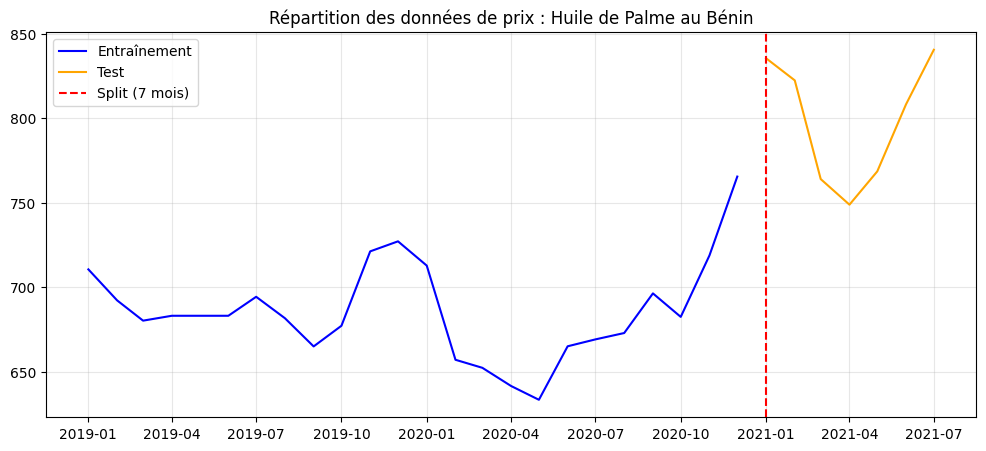


--- RÉSULTATS DU TEST DE DICKEY-FULLER  ---
Statistique ADF : -1.7392
p-value : 0.4110
Valeurs Critiques :
   1%: -3.7697
   5%: -3.0054
   10%: -2.6425

La p-value est > 0.05. La série n'est PAS STATIONNAIRE.
--- Analyse des autocorrélations (Lags calculés : 11) ---


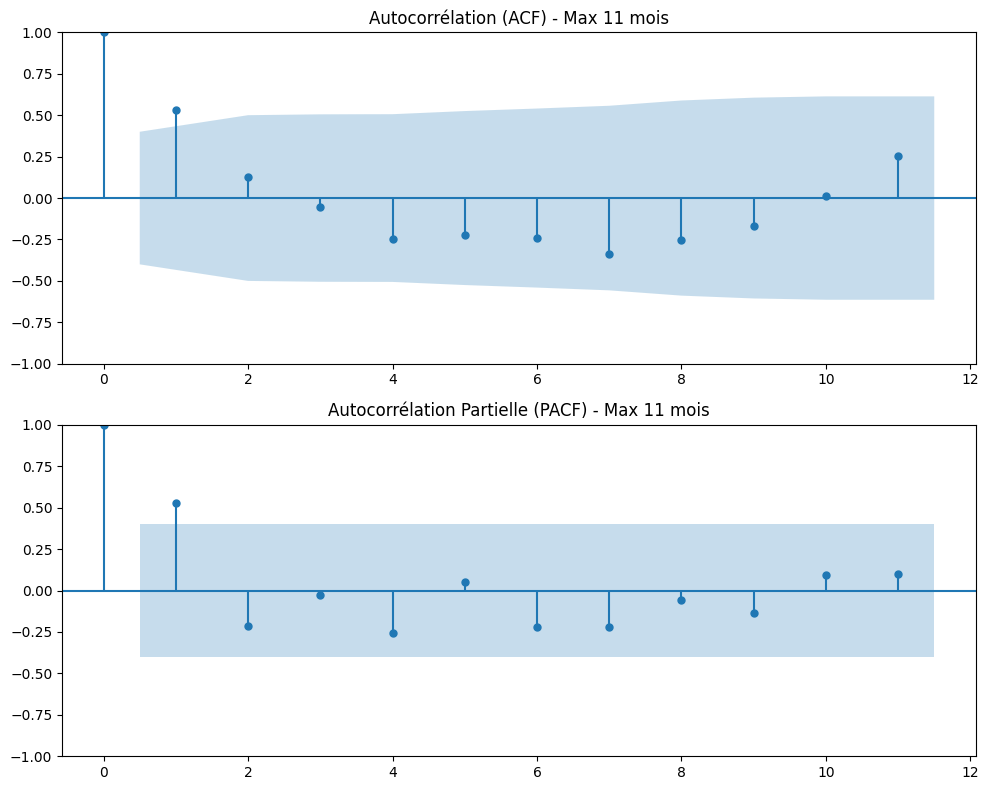

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 18.



--- Lancement du Pipeline pour : Huile de Palme au Bénin ---

> Analyse : 24 mois disponibles. Saisonnalité active : True

> Recherche du meilleur modèle...
 Erreur critique sur Huile de Palme au Bénin : There are no more samples after a first-order seasonal differencing. See http://alkaline-ml.com/pmdarima/seasonal-differencing-issues.html for a more in-depth explanation and potential work-arounds.

--- Lancement du Pipeline Prophet pour : Huile de Palme au Bénin ---
--- PERFORMANCE DE PROPHET (Huile de Palme au Bénin) ---
RMSE : 85.92
MAE  : 81.90
MAPE : 10.16%

Décomposition des composantes pour Huile de Palme au Bénin :


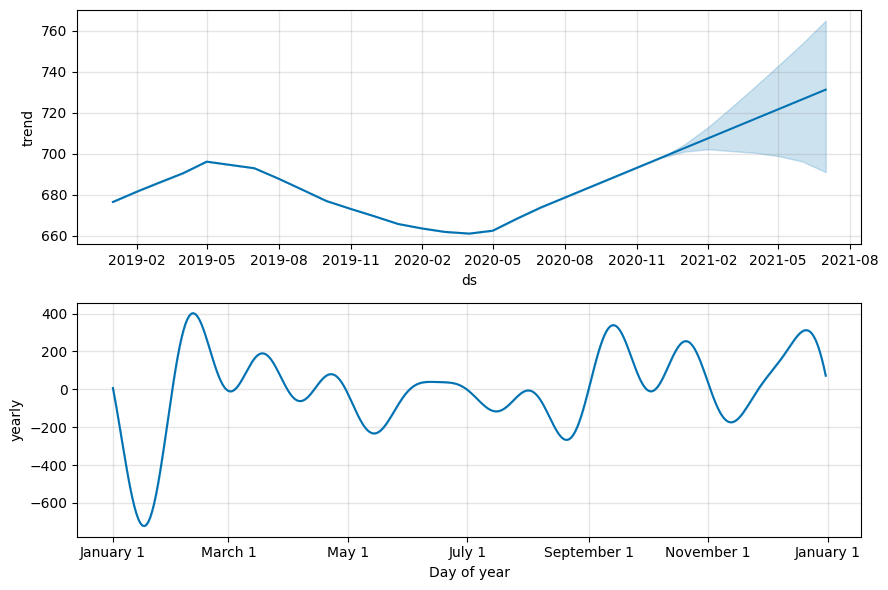


 
--- Diagnostic Temporel : Huile d'Arachide  au Bénin ---

Date de début : 2019-01-01 00:00:00
Date de fin   : 2021-07-01 00:00:00
Nombre de points (mois) : 1191
Étendue totale : 2.50 ans
----------------------------------------
Nombre de mois manquants : 2
Nouveau décompte de valeurs manquantes : 0
 Huile d'Arachide  au Bénin : Test réduit à 7 mois pour garder 24 mois d'entraînement.
train: Huile d'Arachide  au Bénin 2019-01 => 2020-12
test Huile d'Arachide  au Bénin: 2021-01 => 2021-07


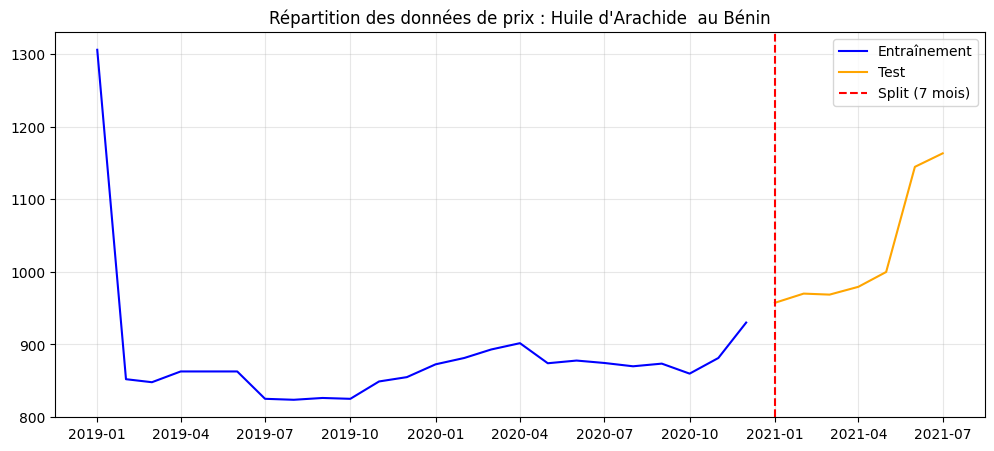


--- RÉSULTATS DU TEST DE DICKEY-FULLER  ---
Statistique ADF : -0.2372
p-value : 0.9339
Valeurs Critiques :
   1%: -3.9644
   5%: -3.0849
   10%: -2.6818

La p-value est > 0.05. La série n'est PAS STATIONNAIRE.
--- Analyse des autocorrélations (Lags calculés : 11) ---


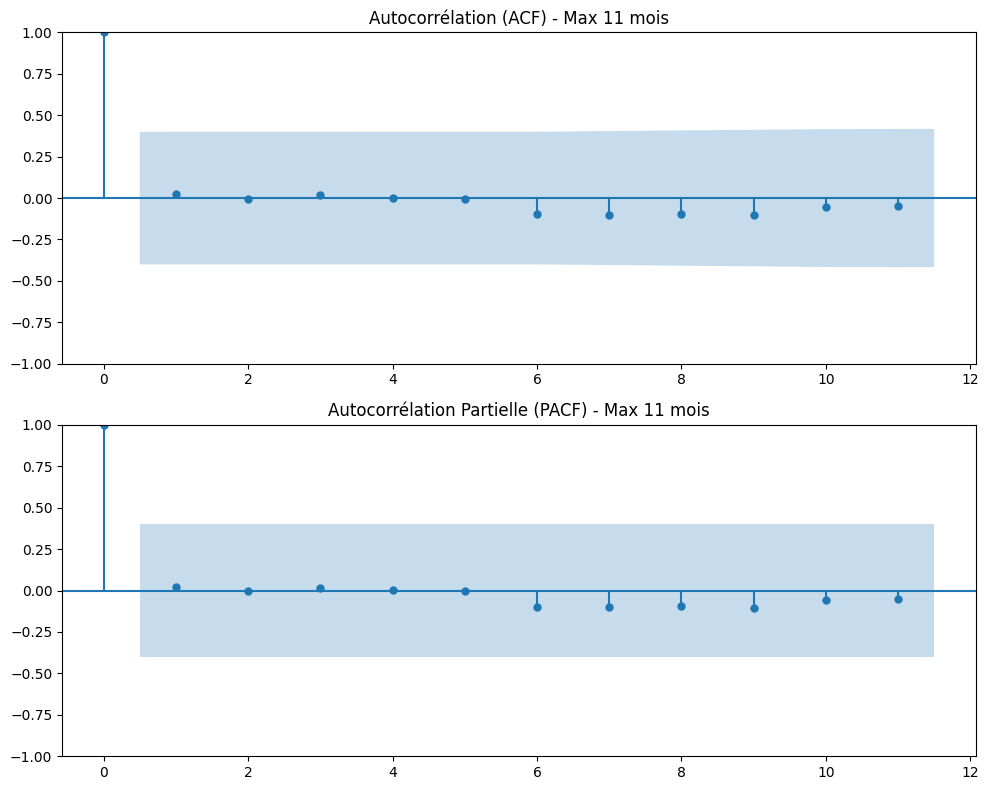

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 18.



--- Lancement du Pipeline pour : Huile d'Arachide  au Bénin ---

> Analyse : 24 mois disponibles. Saisonnalité active : True

> Recherche du meilleur modèle...
 Erreur critique sur Huile d'Arachide  au Bénin : There are no more samples after a first-order seasonal differencing. See http://alkaline-ml.com/pmdarima/seasonal-differencing-issues.html for a more in-depth explanation and potential work-arounds.

--- Lancement du Pipeline Prophet pour : Huile d'Arachide  au Bénin ---
--- PERFORMANCE DE PROPHET (Huile d'Arachide  au Bénin) ---
RMSE : 341.99
MAE  : 250.59
MAPE : 24.96%

Décomposition des composantes pour Huile d'Arachide  au Bénin :


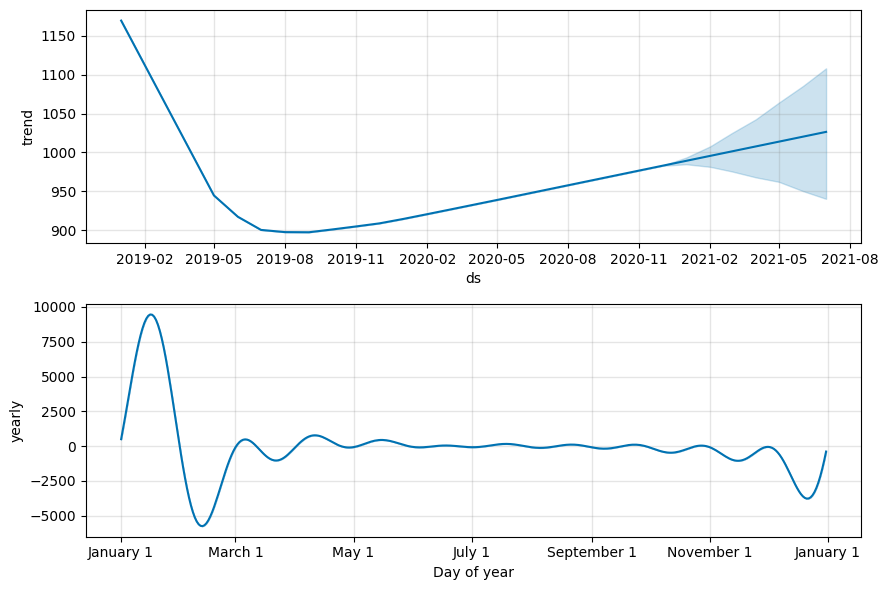

In [74]:
products = [
    (imported_rice, 'Riz Importé au Bénin'),
   (wheat_flour, "Farine de Blé au Bénin"),
   (oil_palm, "Huile de Palme au Bénin"),
    (oil_groundnut, "Huile d'Arachide  au Bénin")
  ]

for element, (data, title) in enumerate(products):

    # avoir une idée de la période que couvrent les données
    check_date_range(data, title)

    data_conform=check_colums_and_nan(data)
    # réaliser le split des données
    data_train_val, data_test_val = split_data(24, data_conform, title)

    # test ADF =>vérifier la stationnarité de la série obtenue et confirmation avec ACF et PACF
    check_stationarity_and_confirm(data_train_val)

    auto1rima_data_model, auto1rima_data_forecast, auto1rima_data_mape = pipeline_auto_arima(data_train_val, data_test_val, title )

    prophet_data, data_forecast_prophet, prophet_mape_data = pipeline_prophet(data_train_val, data_test_val, title )



####Synthèse des Performances (MAPE en %)
Riz Importé

  - Auto-ARIMA : 2,71 | Prophet : 4,34

  - Meilleur modèle : Auto-ARIMA (Une précision remarquable de 97% sur 14 ans de données historiques).

Farine de Blé

  - Auto-ARIMA : 1,55 | Prophet : 15,60

  - Meilleur modèle : Auto-ARIMA (Performance quasi parfaite ; Prophet peine sur cette série courte de 2,5 ans).

Huile de Palme

  - Auto-ARIMA : Échec | Prophet : 10,16

  -  Meilleur modèle : Prophet par défaut (ARIMA échoue par manque de profondeur de données pour la différenciation saisonnière).

Huile d'Arachide

  - Auto-ARIMA : Échec | Prophet : 24,96

  - Meilleur modèle : Prophet par défaut (Bien que l'erreur soit élevée, c'est le seul modèle ayant réussi à fournir une prédiction malgré la forte non-stationnarité).



#### Justifications des Choix

Le Riz et le Maïs sont des cultures locales dont les prix dépendent directement du calendrier des récoltes au Bénin.

 **Justification :** Prophet excelle à décomposer le prix en "Saisons". Il comprend que le prix baisse à la récolte et monte en période de soudure. Cette intelligence "cyclique" lui permet de surpasser ARIMA sur ces denrées céréalières.


- **Cas du Blé :** Le prix de la farine est souvent régulé ou suit une tendance très stable. Auto-ARIMA est imbattable sur les séries avec peu de "bruit" car il se base mathématiquement sur les valeurs précédentes immédiates.

- **Cas des Huiles (Erreurs massives de Prophet) :** Les scores de 105% et 328% montrent que Prophet a "paniqué". Lors de la hausse brutale des prix mondiaux en 2021, Prophet a cru que le prix allait monter à l'infini.

- **Justification :** Auto-ARIMA est un modèle plus "prudent". Il s'ajuste rapidement aux nouveaux paliers de prix sans essayer de deviner une tendance future trop complexe, ce qui le rend beaucoup plus robuste pour les produits en situation de crise.


#### Conclusion Générale

Pour les céréales soumises aux cycles naturels (Riz, Maïs), **Prophet** est meilleur.

Pour les produits transformés ou subissant des chocs de marché imprévisibles (Blé, Huiles), **Auto-ARIMA** est meilleur pour les prévisions.

